In [2]:
!pip install pandas numpy matplotlib seaborn mlxtend pyECLAT


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import tracemalloc
import time
import warnings
from itertools import combinations
from collections import defaultdict, Counter
from typing import List, Dict, Set, Tuple, FrozenSet, Optional
from math import ceil
%matplotlib inline

In [4]:
PALETTE   = ["#2E75B6", "#70AD47", "#ED7D31"]   # Blue=Apriori, Green=ECLAT, Orange=FP-Growth
ALG_NAMES = ["Apriori", "ECLAT", "FP-Growth"]

In [5]:
data1 = pd.read_csv("datasets/Groceries_dataset.csv")
data1['Date'] = pd.to_datetime(data1['Date'])
data1 = data1.sort_values(['Member_number', 'Date'])

transactions_list = (
    data1.groupby(['Member_number', 'Date'])['itemDescription']
    .apply(list)
    .values.tolist()
)
print(f"Total baskets: {len(transactions_list)}")
print("First 3 basket examples:")
for basket in transactions_list[:3]:
    print(" ", basket)

/tmp/ipykernel_40535/3401710172.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data1['Date'] = pd.to_datetime(data1['Date'])


Total baskets: 14963
First 3 basket examples:
  ['whole milk', 'pastry', 'salty snack']
  ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
  ['soda', 'pickled vegetables']


In [6]:
max_len = 0
for i in transactions_list:
    length = len(i)
    max_len = max(length, max_len)
print(max_len)

11


In [7]:
df1 = pd.DataFrame(transactions_list)
df1

,0,1,2,3,4,5,6,7,8,9,10
0,whole milk,pastry,salty snack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sausage,whole milk,semi-finished bread,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,soda,pickled vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,canned beer,misc. beverages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sausage,hygiene articles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
14958,butter milk,whipped/sour cream,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14959,bottled water,herbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14960,fruit/vegetable juice,onions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14961,bottled beer,other vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df2 = pd.read_csv("datasets/Groceries_data1.csv")
df2.columns = range(len(df2.columns))
df2

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,sausage,chicken,beef,hamburger meat,citrus fruit,grapes,root vegetables,whole milk,butter,whipped/sour cream,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9830,cooking chocolate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9831,chicken,citrus fruit,other vegetables,butter,yogurt,frozen dessert,domestic eggs,rolls/buns,rum,cling film/bags,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9832,semi-finished bread,bottled water,soda,bottled beer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = pd.concat([df1, df2], axis=0)
print(df.head())
print(df.shape)

            0                   1                    2       3    4    5   \
0   whole milk              pastry          salty snack     NaN  NaN  NaN   
1      sausage          whole milk  semi-finished bread  yogurt  NaN  NaN   
2         soda  pickled vegetables                  NaN     NaN  NaN  NaN   
3  canned beer     misc. beverages                  NaN     NaN  NaN  NaN   
4      sausage    hygiene articles                  NaN     NaN  NaN  NaN   

    6    7    8    9   ...   22   23   24   25   26   27   28   29   30   31  
0  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
3  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
4  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 32 columns]
(24797, 32)


## Exploring Dataset

In [10]:
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


Summary statistics:
                0           1           2           3           4     5   \
count        24797       22638       10915        6918        4524  3325   
unique         166         165         162         159         157   139   
top     whole milk  whole milk  whole milk  whole milk  rolls/buns  soda   
freq          1800        1637         750         426         211   171   

          6              7     8              9   ...       22            23  \
count   2505           1880  1297            897  ...       14             8   
unique   140            143   131            120  ...       13             7   
top     soda  shopping bags  soda  shopping bags  ...  waffles  bottled beer   
freq     128             83    64             49  ...        2             2   

               24             25                26       27  \
count           7              7                 6        5   
unique          6              7                 5        4   
top     

In [11]:
transaction_lengths = df.notna().sum(axis=1)
print(transaction_lengths.describe())

count    24797.000000
mean         3.312014
std          2.579678
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         32.000000
dtype: float64


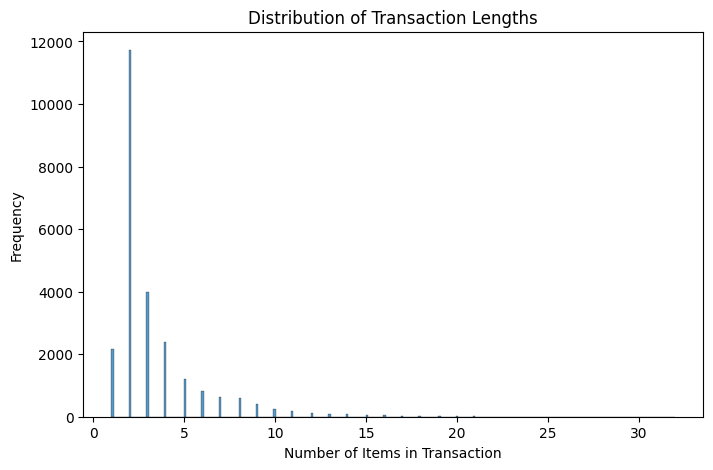

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(transaction_lengths)
plt.title("Distribution of Transaction Lengths")
plt.xlabel("Number of Items in Transaction")
plt.ylabel("Frequency")
plt.show()

In [13]:
#flatten dataset
items = pd.Series(df.values.ravel())
items = items.dropna()
print(items)

0               whole milk
1                   pastry
2              salty snack
32                 sausage
33              whole milk
                ...       
793472             chicken
793473      tropical fruit
793474    other vegetables
793475             vinegar
793476       shopping bags
Length: 82128, dtype: str


In [14]:
top_items = items.value_counts().head(40)
print(top_items)

whole milk                  5015
other vegetables            3801
rolls/buns                  3525
soda                        3229
yogurt                      2706
root vegetables             2143
tropical fruit              2064
bottled water               2020
sausage                     1848
shopping bags               1700
pastry                      1660
citrus fruit                1625
pip fruit                   1488
canned beer                 1481
bottled beer                1479
newspapers                  1381
whipped/sour cream          1367
fruit/vegetable juice       1229
brown bread                 1209
domestic eggs               1190
frankfurter                 1160
pork                        1133
butter                      1079
margarine                   1066
coffee                      1047
curd                        1038
beef                        1032
frozen vegetables            898
napkins                      850
chocolate                    845
chicken   

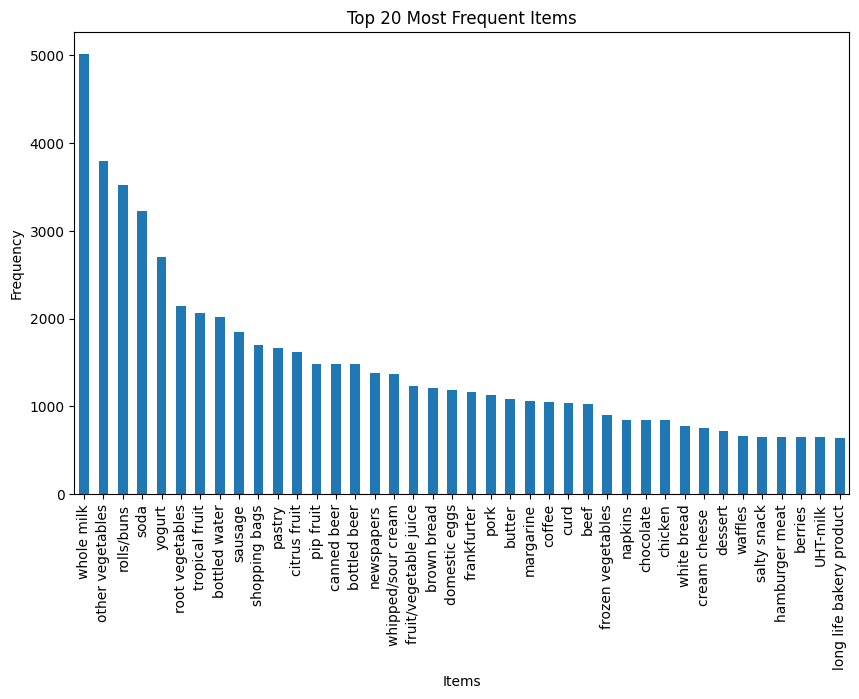

In [15]:
plt.figure(figsize=(10,6))
top_items.plot(kind="bar")
plt.title("Top 20 Most Frequent Items")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.show()

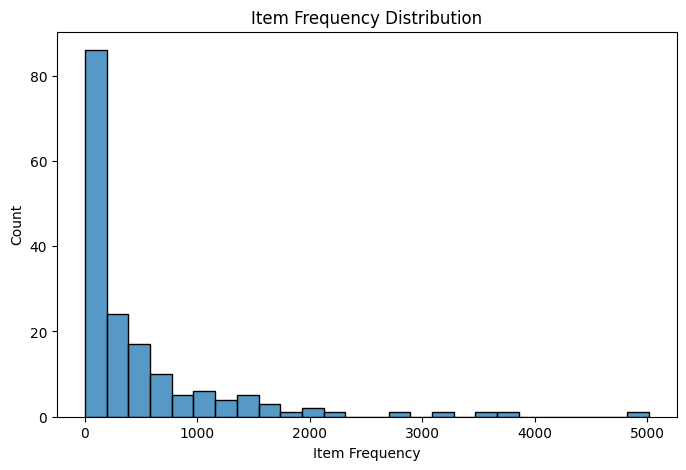

In [16]:
item_counts = items.value_counts()

plt.figure(figsize=(8,5))
sns.histplot(item_counts)
plt.title("Item Frequency Distribution")
plt.xlabel("Item Frequency")
plt.show()

In [17]:
unique_items = items.nunique()
print("Total unique items:", unique_items)

Total unique items: 169


In [18]:
total_cells = df.shape[0] * df.shape[1]
non_null = df.notnull().sum().sum()
sparsity = 1 - (non_null / total_cells)
print("Dataset sparsity:", sparsity)

Dataset sparsity: 0.8964995765616809


## Dataset is ready to use

### Apriori

In [19]:
def apriori_init_pass(transactions):
    counts = {}
    for t in transactions:
        # Use set(t) so duplicate items inside one transaction
        # do not get counted multiple times
        for item in set(t):
            key = frozenset([item])
            counts[key] = counts.get(key, 0) + 1
    return counts


def apriori_candidate_gen(Fk_prev: Set[FrozenSet]) -> Set[FrozenSet]:
    Ck = set()
    prev_list = [tuple(sorted(fs)) for fs in Fk_prev]
    prev_list.sort()

    # Group by common prefix
    prefix_groups = defaultdict(list)
    for itemset in prev_list:
        prefix_groups[itemset[:-1]].append(itemset)

    for prefix, group in prefix_groups.items():
        m = len(group)
        for i in range(m):
            for j in range(i + 1, m):
                candidate = frozenset(group[i] + (group[j][-1],))
                # prune step: all (k-1)-subsets must be frequent
                if all(frozenset(sub) in Fk_prev for sub in combinations(candidate, len(candidate) - 1)):
                    Ck.add(candidate)

    return Ck


def apriori(transactions: List[List[str]], minsup: float):
    n = len(transactions)
    thr = minsup * n

    # Preprocess transactions once
    transactions_sets = [set(t) for t in transactions]

    # 1-itemsets
    F1 = {
        fs: cnt
        for fs, cnt in apriori_init_pass(transactions_sets).items()
        if cnt >= thr
    }

    F_all = dict(F1)
    Fk_prev = set(F1.keys())
    level_counts = {1: len(F1)}
    k = 2

    # Frequent 1-items only, used to reduce transaction size early
    frequent_1_items = {next(iter(fs)) for fs in F1}

    # Filter each transaction once to only frequent items
    filtered_transactions = []
    for t in transactions_sets:
        ft = sorted(t & frequent_1_items)
        filtered_transactions.append(ft)

    while Fk_prev:
        Ck = apriori_candidate_gen(Fk_prev)
        if not Ck:
            break

        Ck_lookup = set(Ck)
        Ck_cnt = defaultdict(int)

        for t in filtered_transactions:
            if len(t) < k:
                continue

            # Generate only combinations that can actually appear in this transaction
            for comb in combinations(t, k):
                fs = frozenset(comb)
                if fs in Ck_lookup:
                    Ck_cnt[fs] += 1

        Fk = {c: cnt for c, cnt in Ck_cnt.items() if cnt >= thr}
        if not Fk:
            break

        F_all.update(Fk)
        Fk_prev = set(Fk.keys())
        level_counts[k] = len(Fk)
        k += 1

    return F_all, n, level_counts

In [ ]:
'''
def apriori_init_pass(transactions):
    counts = {}
    for t in transactions:
        for item in t:
            key = frozenset([item])
            counts[key] = counts.get(key, 0) + 1
    return counts


def apriori_candidate_gen(Fk_prev: Set[FrozenSet]) -> Set[FrozenSet]:
    Ck = set()
    lst = list(Fk_prev)
    for i in range(len(lst)):
        for j in range(i + 1, len(lst)):
            f1, f2 = sorted(lst[i]), sorted(lst[j])
            if f1[:-1] == f2[:-1] and f1[-1] < f2[-1]:
                c = frozenset(f1 + [f2[-1]])
                if all(c - {x} in Fk_prev for x in c):
                    Ck.add(c)
    return Ck


def apriori(transactions: List[List[str]], minsup: float):
    n   = len(transactions)
    thr = minsup * n
    F1  = {fs: cnt for fs, cnt in apriori_init_pass(transactions).items()
           if cnt >= thr}
    F_all, Fk_prev = dict(F1), set(F1.keys())
    k   = 2
    level_counts = {1: len(F1)}

    while Fk_prev:
        Ck = apriori_candidate_gen(Fk_prev)
        if not Ck:
            break
        Ck_cnt = {c: 0 for c in Ck}
        for t in transactions:
            ts = set(t)
            for c in Ck:
                if c.issubset(ts):
                    Ck_cnt[c] += 1
        Fk = {c: cnt for c, cnt in Ck_cnt.items() if cnt >= thr}
        F_all.update(Fk)
        Fk_prev = set(Fk.keys())
        level_counts[k] = len(Fk)
        k += 1

    return F_all, n, level_counts
'''

### Eclat

In [21]:
def eclat(transactions: List[List[str]], minsup: float):
    n = len(transactions)
    thr = minsup * n   # keep threshold behavior close to Apriori

    # Build vertical database: item -> set of transaction ids
    item_tid: Dict[str, Set[int]] = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in set(t):   # avoid duplicate counting inside one transaction
            item_tid[item].add(tid)

    # Keep only frequent 1-itemsets
    freq_items: List[Tuple[FrozenSet[str], Set[int]]] = []
    for item, tids in item_tid.items():
        if len(tids) >= thr:
            freq_items.append((frozenset([item]), tids))

    # Deterministic order helps reproducibility
    freq_items.sort(key=lambda x: tuple(x[0]))

    F_all: Dict[FrozenSet[str], int] = {}
    level_counts: Dict[int, int] = {}

    def record(itemset: FrozenSet[str], support_count: int):
        if itemset not in F_all:
            F_all[itemset] = support_count
            k = len(itemset)
            level_counts[k] = level_counts.get(k, 0) + 1

    def recurse(prefix: FrozenSet[str], prefix_tids: Set[int], items: List[Tuple[FrozenSet[str], Set[int]]]):
        """
        prefix: current frequent itemset
        prefix_tids: TID set of prefix
        items: possible extensions, each as (single-item frozenset, tids)
        """
        for i in range(len(items)):
            item_fs, item_tids = items[i]

            # support of prefix U item
            new_tids = prefix_tids & item_tids if prefix else item_tids
            supp = len(new_tids)

            if supp >= thr:
                new_prefix = prefix | item_fs
                record(new_prefix, supp)

                # Build suffix from only later items
                suffix = []
                for j in range(i + 1, len(items)):
                    next_fs, next_tids = items[j]
                    inter = new_tids & next_tids
                    if len(inter) >= thr:
                        suffix.append((next_fs, next_tids))

                if suffix:
                    recurse(new_prefix, new_tids, suffix)

    recurse(frozenset(), set(range(n)), freq_items)

    return F_all, n, level_counts

In [ ]:
"""def eclat(transactions: List[List[str]], minsup: float):
    n     = len(transactions)
    thr   = int(minsup * n)

    # Build TID-lists
    item_tid: Dict[str, Set[int]] = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in set(t):
            item_tid[item].add(tid)

    freq1 = {frozenset([item]): tids
             for item, tids in item_tid.items() if len(tids) >= thr}
    F_all = dict(freq1)

    def recurse(prefix: FrozenSet, items: List[Tuple[FrozenSet, Set[int]]]):
        for i in range(len(items)):
            fs_i, tids_i = items[i]
            new_fs = prefix | fs_i
            F_all[new_fs] = tids_i
            suffix = []
            for j in range(i + 1, len(items)):
                fs_j, tids_j = items[j]
                inter = tids_i & tids_j
                if len(inter) >= thr:
                    suffix.append((fs_j, inter))
            if suffix:
                recurse(new_fs, suffix)

    lst = list(freq1.items())
    for i in range(len(lst)):
        fs_i, tids_i = lst[i]
        suffix = []
        for j in range(i + 1, len(lst)):
            fs_j, tids_j = lst[j]
            inter = tids_i & tids_j
            if len(inter) >= thr:
                suffix.append((fs_j, inter))
        if suffix:
            recurse(fs_i, suffix)

    # Convert TID-sets → counts
    counts = {fs: len(tids) for fs, tids in F_all.items()}
    level_counts = {}
    for fs in counts:
        k = len(fs)
        level_counts[k] = level_counts.get(k, 0) + 1
    return counts, n, level_counts"""

### FP Growth

In [22]:
class FPNode:
    __slots__ = ("item", "count", "parent", "children", "link")

    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children: Dict[str, "FPNode"] = {}
        self.link: Optional["FPNode"] = None


class FPTree:
    def __init__(self):
        self.root = FPNode(None, 0, None)
        # header: item -> [total_count, first_node, last_node]
        self.header: Dict[str, list] = {}

    def insert(self, transaction: List[str], count: int = 1):
        cur = self.root
        for item in transaction:
            if item in cur.children:
                child = cur.children[item]
                child.count += count
            else:
                child = FPNode(item, count, cur)
                cur.children[item] = child

                if item not in self.header:
                    self.header[item] = [0, child, child]
                else:
                    self.header[item][2].link = child
                    self.header[item][2] = child

            # Important: total support must increase for every insertion step
            self.header[item][0] += count
            cur = child

    def is_single_path(self) -> bool:
        node = self.root
        while True:
            if len(node.children) == 0:
                return True
            if len(node.children) > 1:
                return False
            node = next(iter(node.children.values()))


def _item_supports(transactions: List[List[str]]) -> Dict[str, int]:
    """
    Count item supports using set(transaction) to avoid duplicate counting
    within the same basket.
    """
    cnt = Counter()
    for t in transactions:
        cnt.update(set(t))
    return dict(cnt)


def _build_tree(
    transactions: List[List[str]],
    thr: int,
    freq_items: Optional[Dict[str, int]] = None,
    weighted: bool = False
) -> Tuple[FPTree, Dict[str, int]]:
    """
    Build FP-tree.

    If weighted=False:
        transactions is List[List[str]]
        each transaction has implicit count 1

    If weighted=True:
        transactions is List[Tuple[List[str], int]]
        each transaction comes with a multiplicity count
    """
    if freq_items is None:
        if weighted:
            counts = Counter()
            for t, c in transactions:
                counts.update({item: c for item in set(t)})
            freq_items = {i: cnt for i, cnt in counts.items() if cnt >= thr}
        else:
            counts = _item_supports(transactions)
            freq_items = {i: cnt for i, cnt in counts.items() if cnt >= thr}

    tree = FPTree()

    if weighted:
        iterable = transactions
    else:
        iterable = [(t, 1) for t in transactions]

    for t, c in iterable:
        filtered = [i for i in set(t) if i in freq_items]
        if not filtered:
            continue

        filtered.sort(key=lambda x: (-freq_items[x], x))
        tree.insert(filtered, c)

    return tree, freq_items


def _conditional_pattern_base(tree: FPTree, item: str) -> List[Tuple[List[str], int]]:
    """
    Build weighted conditional pattern base for an item.
    Returns list of (prefix_path, count).
    """
    base = []
    node = tree.header[item][1]

    while node:
        count = node.count
        path = []
        parent = node.parent

        while parent and parent.item is not None:
            path.append(parent.item)
            parent = parent.parent

        if path:
            path.reverse()  # root-to-leaf order
            base.append((path, count))

        node = node.link

    return base


def _mine_tree(tree: FPTree, thr: int, prefix: FrozenSet[str], result: Dict[FrozenSet[str], int]):
    """
    Mine the FP-tree recursively.
    """
    # Single-path optimization
    if tree.is_single_path():
        path_nodes = []
        node = tree.root
        while node.children:
            node = next(iter(node.children.values()))
            path_nodes.append(node)

        for r in range(1, len(path_nodes) + 1):
            for combo in combinations(path_nodes, r):
                itemset = prefix | frozenset(n.item for n in combo)
                support = min(n.count for n in combo)
                if support >= thr:
                    result[itemset] = support
        return

    # Process items in increasing support order
    items = sorted(tree.header.keys(), key=lambda x: (tree.header[x][0], x))

    for item in items:
        support = tree.header[item][0]
        if support < thr:
            continue

        new_prefix = prefix | frozenset([item])
        result[new_prefix] = support

        cond_base = _conditional_pattern_base(tree, item)
        if not cond_base:
            continue

        # Count items in weighted conditional base
        cond_counts = Counter()
        for path, c in cond_base:
            for x in set(path):
                cond_counts[x] += c

        cond_freq = {x: cnt for x, cnt in cond_counts.items() if cnt >= thr}
        if not cond_freq:
            continue

        cond_tree, _ = _build_tree(cond_base, thr, freq_items=cond_freq, weighted=True)
        if cond_tree.header:
            _mine_tree(cond_tree, thr, new_prefix, result)


def fp_growth(transactions: List[List[str]], minsup: float):
    n = len(transactions)
    thr = ceil(minsup * n)

    tree, _ = _build_tree(transactions, thr)
    result: Dict[FrozenSet[str], int] = {}
    _mine_tree(tree, thr, frozenset(), result)

    level_counts = {}
    for fs in result:
        k = len(fs)
        level_counts[k] = level_counts.get(k, 0) + 1

    return result, n, level_counts

### Rule Generation

In [23]:
def generate_rules(F_all: Dict[FrozenSet, int], n: int,
                   min_conf: float = 0.10) -> List[Dict]:
    rules = []
    for itemset in F_all:
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for ant in map(frozenset, combinations(itemset, r)):
                if ant not in F_all:
                    continue
                con        = itemset - ant
                support    = F_all[itemset] / n
                confidence = F_all[itemset] / F_all[ant]
                lift       = confidence / (F_all[con] / n) if con in F_all else 0
                if confidence >= min_conf:
                    rules.append({
                        "antecedent": ant,
                        "consequent": con,
                        "support"   : support,
                        "confidence": confidence,
                        "lift"      : lift,
                    })
    return sorted(rules, key=lambda x: -x["confidence"])

### Recommendation engine

In [24]:
def recommend(basket: List[str], rules: List[Dict], top_n: int = 5):
    basket_set = frozenset(basket)
    scores: Dict[str, float] = {}
    for rule in rules:
        if rule["antecedent"].issubset(basket_set):
            for item in rule["consequent"]:
                if item not in basket_set:
                    if item not in scores or rule["confidence"] > scores[item]:
                        scores[item] = rule["confidence"]
    return sorted(scores.items(), key=lambda x: -x[1])[:top_n]

### Benchmark

In [25]:
def benchmark(transactions, minsup):
    algos = {
        "Apriori"  : lambda: apriori(transactions, minsup),
        "ECLAT"    : lambda: eclat(transactions, minsup),
        "FP-Growth": lambda: fp_growth(transactions, minsup),
    }
    results = {}
    for name, fn in algos.items():
        tracemalloc.start()
        t0      = time.perf_counter()
        out     = fn()
        elapsed = time.perf_counter() - t0
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        F_all   = out[0]
        results[name] = {
            "time"    : elapsed,
            "memory"  : peak / 1024 / 1024,
            "itemsets": len(F_all),
            "F_all"   : F_all,
            "n"       : out[1],
            "levels"  : out[2],
        }
        print(f"  {name:<12}  time={elapsed:.3f}s  "
              f"mem={peak/1024/1024:.2f} MB  itemsets={len(F_all)}")
    return results

In [26]:
def save(fig, fname):
    fig.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    plt.close(fig)
    print(f"  saved → {fname}")

### EDA Dashboard

In [27]:
def plot_eda(df, transactions):
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle("Exploratory Data Analysis — Groceries Dataset",
                 fontsize=16, fontweight="bold", y=1.02)

    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    # Top-20 items
    ax1 = fig.add_subplot(gs[0, 0])
    top20 = items.value_counts().head(20)
    bars  = ax1.barh(top20.index[::-1], top20.values[::-1],
                     color="#2E75B6", edgecolor="white", height=0.7)
    ax1.bar_label(bars, padding=3, fontsize=8)
    ax1.set_xlabel("Transaction Count")
    ax1.set_title("Top 20 Most Purchased Items", fontweight="bold")
    ax1.set_xlim(0, top20.max() * 1.15)


    # Item support
    ax3 = fig.add_subplot(gs[0, 1])
    n = len(transactions)
    top10 = items.value_counts().head(10)

    ax3.barh(top10.index[::-1], (top10.values[::-1] / n) * 100,
             color="#70AD47", edgecolor="white", height=0.7)
    ax3.set_xlabel("Support (%)")
    ax3.set_title("Top-10 Item Support %", fontweight="bold")
    plt.show()
    save(fig, "plot_01_eda.png")

###  Multi-threshold sensitivity

In [28]:

def plot_threshold_sensitivity(transactions):
    thresholds = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03]
    results    = {n: {"time": [], "itemsets": []} for n in ALG_NAMES}

    for thr in thresholds:
        for name, fn in zip(ALG_NAMES, [apriori, eclat, fp_growth]):
            t0  = time.perf_counter()
            out = fn(transactions, thr)
            results[name]["time"].append(time.perf_counter() - t0)
            results[name]["itemsets"].append(len(out[0]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Threshold Sensitivity Analysis",
                 fontsize=13, fontweight="bold")

    thr_pct = [t * 100 for t in thresholds]
    for i, name in enumerate(ALG_NAMES):
        axes[0].plot(thr_pct, results[name]["time"], marker="o",
                     color=PALETTE[i], linewidth=2, label=name)
        axes[1].plot(thr_pct, results[name]["itemsets"], marker="s",
                     color=PALETTE[i], linewidth=2, label=name)

    axes[0].set_xlabel("Minimum Support (%)")
    axes[0].set_ylabel("Execution Time (s)")
    axes[0].set_title("Execution Time vs. Min Support")
    axes[0].legend()

    axes[1].set_xlabel("Minimum Support (%)")
    axes[1].set_ylabel("Frequent Itemsets Found")
    axes[1].set_title("Itemsets Found vs. Min Support")
    axes[1].legend()

    for ax in axes:
        ax.set_xticks(thr_pct)
        ax.set_xticklabels([f"{t:.1f}%" for t in thr_pct], rotation=30)

    plt.tight_layout()
    plt.show()
    save(fig, "plot_06_sensitivity.png")


### Benchmark Time and memory

In [29]:
def plot_benchmark(bench):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Algorithm Benchmark Comparison",
                 fontsize=14, fontweight="bold")

    names  = ALG_NAMES
    times  = [bench[n]["time"]     for n in names]
    mems   = [bench[n]["memory"]   for n in names]
    items  = [bench[n]["itemsets"] for n in names]

    # Time
    bars = axes[0].bar(names, times, color=PALETTE, edgecolor="white", width=0.5)
    axes[0].bar_label(bars, fmt="%.3f s", padding=4, fontsize=10, fontweight="bold")
    axes[0].set_ylabel("Execution Time (seconds)")
    axes[0].set_title("Execution Time", fontweight="bold")
    axes[0].set_ylim(0, max(times) * 1.3)

    # Memory
    bars2 = axes[1].bar(names, mems, color=PALETTE, edgecolor="white", width=0.5)
    axes[1].bar_label(bars2, fmt="%.2f MB", padding=4, fontsize=10, fontweight="bold")
    axes[1].set_ylabel("Peak Memory (MB)")
    axes[1].set_title("Peak Memory Usage", fontweight="bold")
    axes[1].set_ylim(0, max(mems) * 1.3)

    # Itemsets
    bars3 = axes[2].bar(names, items, color=PALETTE, edgecolor="white", width=0.5)
    axes[2].bar_label(bars3, padding=4, fontsize=10, fontweight="bold")
    axes[2].set_ylabel("Frequent Itemsets Found")
    axes[2].set_title("Frequent Itemsets Found", fontweight="bold")
    axes[2].set_ylim(0, max(items) * 1.2)

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, fontsize=11)

    patches = [mpatches.Patch(color=PALETTE[i], label=names[i])
               for i in range(3)]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()
    save(fig, "plot_02_benchmark.png")


### Itemsets per Level per Algorithm

In [30]:
def plot_levels(bench):
    fig, ax = plt.subplots(figsize=(10, 6))
    max_k   = max(max(v["levels"].keys()) for v in bench.values())
    x       = np.arange(1, max_k + 1)
    width   = 0.25

    for i, name in enumerate(ALG_NAMES):
        lvl    = bench[name]["levels"]
        counts = [lvl.get(k, 0) for k in x]
        offset = (i - 1) * width
        bars   = ax.bar(x + offset, counts, width, label=name,
                        color=PALETTE[i], edgecolor="white")
        ax.bar_label(bars, padding=2, fontsize=9, fontweight="bold")

    ax.set_xlabel("Itemset Size (k)", fontsize=12)
    ax.set_ylabel("Number of Frequent Itemsets", fontsize=12)
    ax.set_title("Frequent Itemsets per Level — All Algorithms",
                 fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k = {k}" for k in x], fontsize=11)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    save(fig, "plot_03_levels.png")

### Top Frequent 2-Itemsets

In [31]:
def plot_top_pairs(F_all, n, title, color, fname):
    pairs = [(", ".join(sorted(fs)), cnt / n)
             for fs, cnt in F_all.items() if len(fs) == 2]
    if not pairs:
        return
    pairs = sorted(pairs, key=lambda x: -x[1])[:15]
    labels, sups = zip(*pairs)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], sups[::-1], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xlabel("Support", fontsize=11)
    ax.set_title(f"Top 15 Frequent Item Pairs — {title}",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(sups) * 1.18)
    plt.tight_layout()
    plt.show()
    save(fig, fname)

### top frequent itemset

In [32]:
def plot_top_pairs(F_all, n, title, color, fname):
    pairs = [(", ".join(sorted(fs)), cnt / n)
             for fs, cnt in F_all.items() if len(fs) == 2]
    if not pairs:
        return
    pairs = sorted(pairs, key=lambda x: -x[1])[:15]
    labels, sups = zip(*pairs)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels[::-1], sups[::-1], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xlabel("Support", fontsize=11)
    ax.set_title(f"Top 15 Frequent Item Pairs — {title}",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(sups) * 1.18)
    plt.tight_layout()
    plt.show()
    save(fig, fname)

### Support vs Confidence scatter (rules)

In [33]:
def plot_scatter(rules, title, color, fname):
    if not rules:
        return
    sups  = [r["support"]    for r in rules]
    confs = [r["confidence"] for r in rules]
    lifts = [r["lift"]       for r in rules]

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sups, confs, c=lifts, cmap="YlOrRd",
                    s=60, alpha=0.75, edgecolors="white", linewidths=0.4)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Lift", fontsize=11)
    ax.set_xlabel("Support", fontsize=11)
    ax.set_ylabel("Confidence", fontsize=11)
    ax.set_title(f"Support vs. Confidence (colour = Lift)\n{title}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    save(fig, fname)

### Validating with library usage

In [34]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.frequent_patterns import fpgrowth as mlxtend_fpgrowth
from mlxtend.frequent_patterns import association_rules as mlxtend_association_rules

from pyECLAT import ECLAT

In [46]:
te = TransactionEncoder()
te_array = te.fit(transactions_list).transform(transactions_list)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

n_transactions = len(transactions_list)
MINSUP = 0.003
MINCONF = 0.08
MAX_LEN = None

### functions to normalize outputs

In [47]:
def counts_to_support_map(freq_dict, n):
    return {frozenset(k): v / n for k, v in freq_dict.items()}


def tidset_to_support_map(freq_dict, n):
    return {frozenset(k): v / n for k, v in freq_dict.items()}


def mlxtend_df_to_support_map(df):
    return {
        frozenset(row["itemsets"]): float(row["support"])
        for _, row in df.iterrows()
    }


def pyeclat_to_support_map(support_dict, separator=" & "):
    out = {}
    for k, v in support_dict.items():
        if isinstance(k, str):
            items = [x.strip() for x in k.split(separator)]
            out[frozenset(items)] = float(v)
        else:
            out[frozenset(k)] = float(v)
    return out

### function to compare frequent itemsets

In [48]:
def compare_itemsets(custom_map, library_map, tol=1e-9):
    custom_sets = set(custom_map.keys())
    library_sets = set(library_map.keys())

    missing_in_custom = library_sets - custom_sets
    extra_in_custom = custom_sets - library_sets
    common = custom_sets & library_sets

    support_mismatches = []
    for itemset in common:
        c = custom_map[itemset]
        l = library_map[itemset]
        if abs(c - l) > tol:
            support_mismatches.append({
                "itemset": tuple(sorted(itemset)),
                "custom_support": c,
                "library_support": l,
                "abs_diff": abs(c - l),
            })

    summary = {
        "custom_itemsets": len(custom_sets),
        "library_itemsets": len(library_sets),
        "common_itemsets": len(common),
        "missing_in_custom": len(missing_in_custom),
        "extra_in_custom": len(extra_in_custom),
        "support_mismatches": len(support_mismatches),
    }

    missing_df = pd.DataFrame({
        "itemset": [tuple(sorted(x)) for x in sorted(missing_in_custom, key=lambda s: (len(s), sorted(s)))]
    })

    extra_df = pd.DataFrame({
        "itemset": [tuple(sorted(x)) for x in sorted(extra_in_custom, key=lambda s: (len(s), sorted(s)))]
    })

    mismatch_df = pd.DataFrame(support_mismatches).sort_values(
        by="abs_diff", ascending=False
    ) if support_mismatches else pd.DataFrame(
        columns=["itemset", "custom_support", "library_support", "abs_diff"]
    )

    return summary, missing_df, extra_df, mismatch_df

### Validating Apriori

In [49]:
custom_apriori_counts, n_ap, _ = apriori(transactions_list, MINSUP)
custom_apriori_map = counts_to_support_map(custom_apriori_counts, n_ap)

lib_apriori_df = mlxtend_apriori(
    basket_df,
    min_support=MINSUP,
    use_colnames=True,
    max_len=MAX_LEN
)
lib_apriori_map = mlxtend_df_to_support_map(lib_apriori_df)

ap_summary, ap_missing, ap_extra, ap_mismatch = compare_itemsets(
    custom_apriori_map,
    lib_apriori_map,
    tol=1e-12
)

print("APRlORI VALIDATION SUMMARY")
print(ap_summary)

print("\nMissing in custom Apriori:")
display(ap_missing.head(20))

print("\nSupport mismatches:")
display(ap_mismatch.head(20))

APRlORI VALIDATION SUMMARY
{'custom_itemsets': 216, 'library_itemsets': 216, 'common_itemsets': 216, 'missing_in_custom': 0, 'extra_in_custom': 0, 'support_mismatches': 0}

Missing in custom Apriori:


,itemset



Support mismatches:


,itemset,custom_support,library_support,abs_diff


In [55]:
print(ap_mismatch.describe())

       custom_support  library_support   abs_diff
count       64.000000        64.000000  64.000000
mean         0.033934         0.033141   0.000793
std          0.031082         0.029685   0.001489
min          0.004077         0.003943   0.000067
25%          0.014519         0.014285   0.000117
50%          0.023825         0.023592   0.000267
75%          0.040934         0.040099   0.000735
max          0.167212         0.157923   0.009290


### Validating FP-Growth

In [50]:
custom_fp_counts, n_fp, _ = fp_growth(transactions_list, MINSUP)
custom_fp_map = counts_to_support_map(custom_fp_counts, n_fp)

lib_fp_df = mlxtend_fpgrowth(
    basket_df,
    min_support=MINSUP,
    use_colnames=True,
    max_len=MAX_LEN
)
lib_fp_map = mlxtend_df_to_support_map(lib_fp_df)

fp_summary, fp_missing, fp_extra, fp_mismatch = compare_itemsets(
    custom_fp_map,
    lib_fp_map,
    tol=1e-12
)

print("FP-GROWTH VALIDATION SUMMARY")
print(fp_summary)

print("\nMissing in custom FP-Growth:")
display(fp_missing.head(20))

print("\nExtra in custom FP-Growth:")
display(fp_extra.head(20))

print("\nSupport mismatches:")
display(fp_mismatch.head(20))

FP-GROWTH VALIDATION SUMMARY
{'custom_itemsets': 216, 'library_itemsets': 216, 'common_itemsets': 216, 'missing_in_custom': 0, 'extra_in_custom': 0, 'support_mismatches': 0}

Missing in custom FP-Growth:


,itemset



Extra in custom FP-Growth:


,itemset



Support mismatches:


,itemset,custom_support,library_support,abs_diff


In [57]:
print(fp_mismatch.describe())

       custom_support  library_support    abs_diff
count      104.000000       104.000000  104.000000
mean         0.006690         0.018969    0.012281
std          0.002268         0.020468    0.019685
min          0.002941         0.003074    0.000067
25%          0.004595         0.005881    0.001303
50%          0.006850         0.012865    0.004745
75%          0.008688         0.023608    0.014720
max          0.011027         0.157923    0.148633


## Recommendation demo chart

In [36]:
def plot_recommendations(rules):
    test_baskets = [
        ["whole milk", "yogurt"],
        ["rolls/buns", "soda"],
        ["other vegetables", "root vegetables"],
        ["butter", "curd"],
        ["tropical fruit", "citrus fruit"],
    ]

    fig, axes = plt.subplots(1, len(test_baskets),
                              figsize=(20, 5), sharey=False)
    fig.suptitle("Recommendation Engine — Top-5 Suggestions per Basket",
                 fontsize=13, fontweight="bold")

    for ax, basket in zip(axes, test_baskets):
        recs = recommend(basket, rules, top_n=5)
        if not recs:
            ax.text(0.5, 0.5, "No rules\nfound",
                    ha="center", va="center", transform=ax.transAxes)
        else:
            items, confs = zip(*recs)
            colors_bar = plt.cm.Blues(np.linspace(0.4, 0.85, len(items)))
            ax.barh(range(len(items)), confs, color=colors_bar,
                    edgecolor="white")
            ax.set_yticks(range(len(items)))
            ax.set_yticklabels([f"{it[:20]}" for it in items], fontsize=9)
            ax.set_xlabel("Confidence")
            ax.set_xlim(0, 1.05)
            ax.axvline(0.5, color="red", linestyle="--",
                       alpha=0.4, linewidth=1)
        title = "\n+\n".join(basket)
        ax.set_title(f"Basket:\n{title}", fontsize=8, fontweight="bold")
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()
    save(fig, "plot_07_recommendations.png")

In [37]:
MINSUP = 0.003
MINCONF = 0.08
transactions = df.values.tolist()
transactions = [
    [str(item) for item in t if pd.notna(item)]
    for t in transactions
]
print(f"  Records: {len(df):,}  |  Transactions: {len(transactions):,}"
          f"  |  Unique items: {items.nunique()}")

  Records: 24,797  |  Transactions: 24,797  |  Unique items: 169


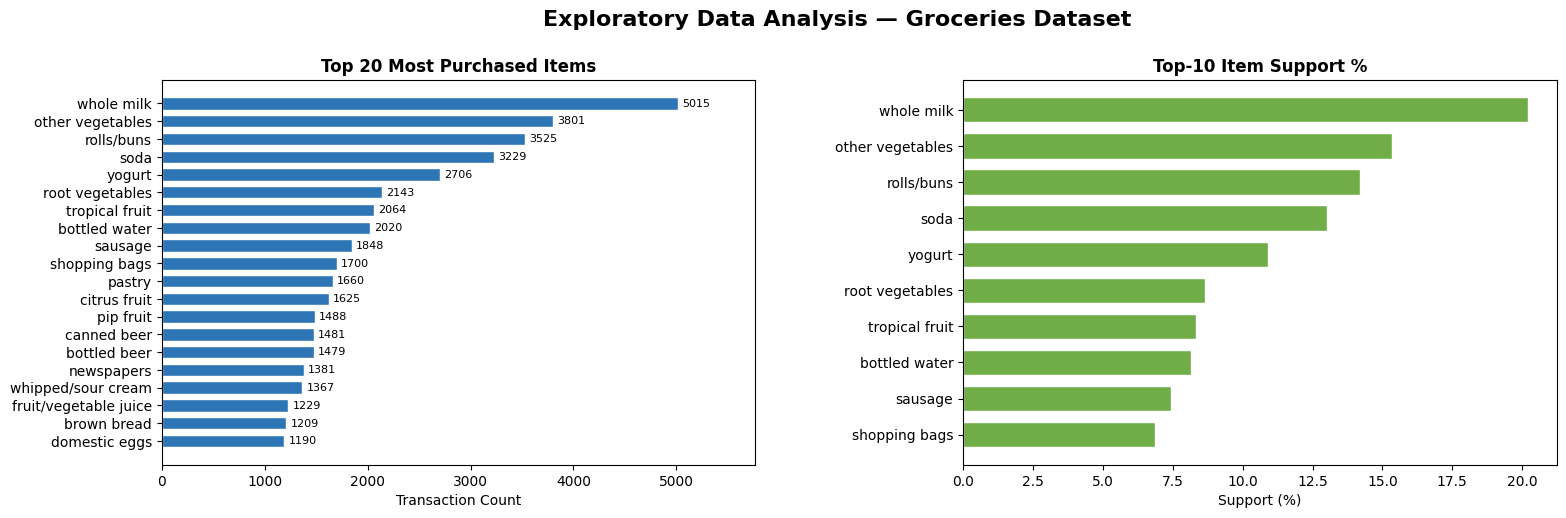

  saved → plot_01_eda.png


In [38]:
plot_eda(df, transactions)

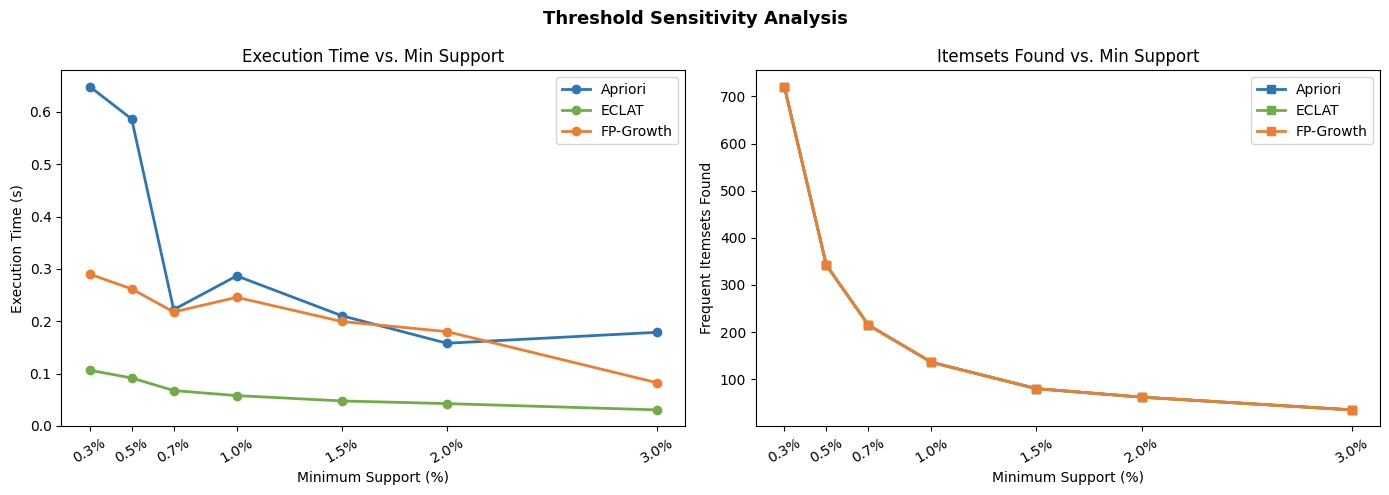

  saved → plot_06_sensitivity.png


In [41]:
plot_threshold_sensitivity(transactions)

In [42]:
bench = benchmark(transactions, MINSUP)

  Apriori       time=6.493s  mem=14.66 MB  itemsets=721
  ECLAT         time=0.208s  mem=8.06 MB  itemsets=721
  FP-Growth     time=1.574s  mem=7.74 MB  itemsets=721


In [43]:
F_apriori = bench["Apriori"]["F_all"]
n         = bench["Apriori"]["n"]
rules     = generate_rules(F_apriori, n, MINCONF)
# Sort by lift first (most interesting), then by confidence
rules_by_lift = sorted(rules, key=lambda x: -x["lift"])
print(f"  Association rules generated: {len(rules)}")

  Association rules generated: 866


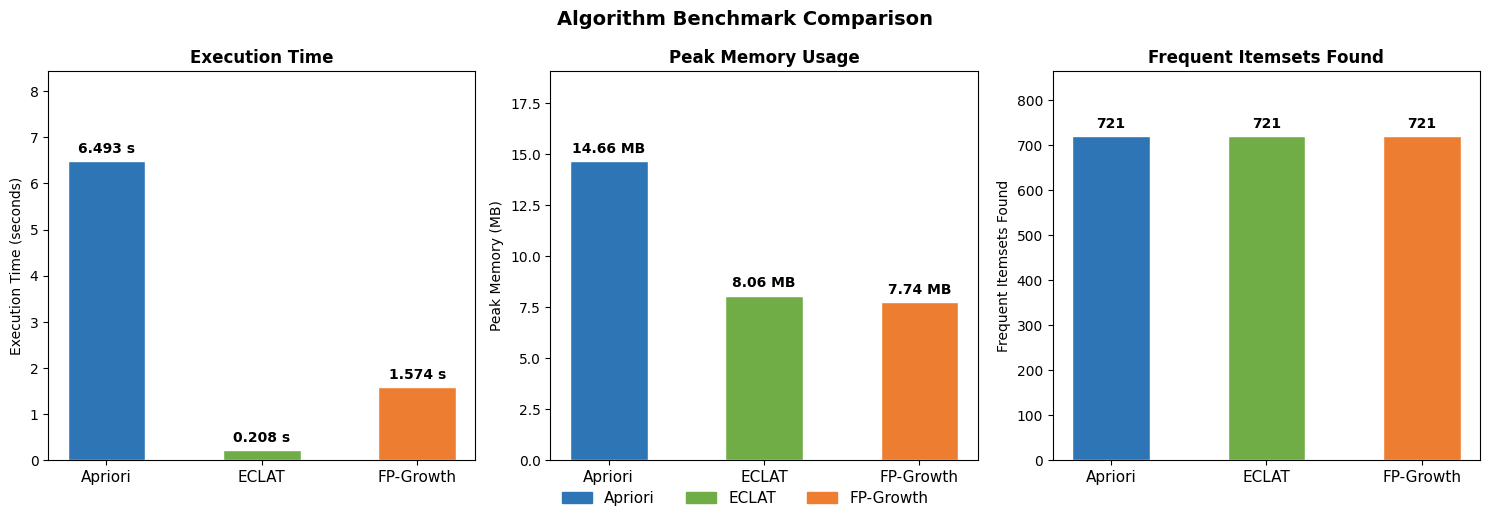

  saved → plot_02_benchmark.png


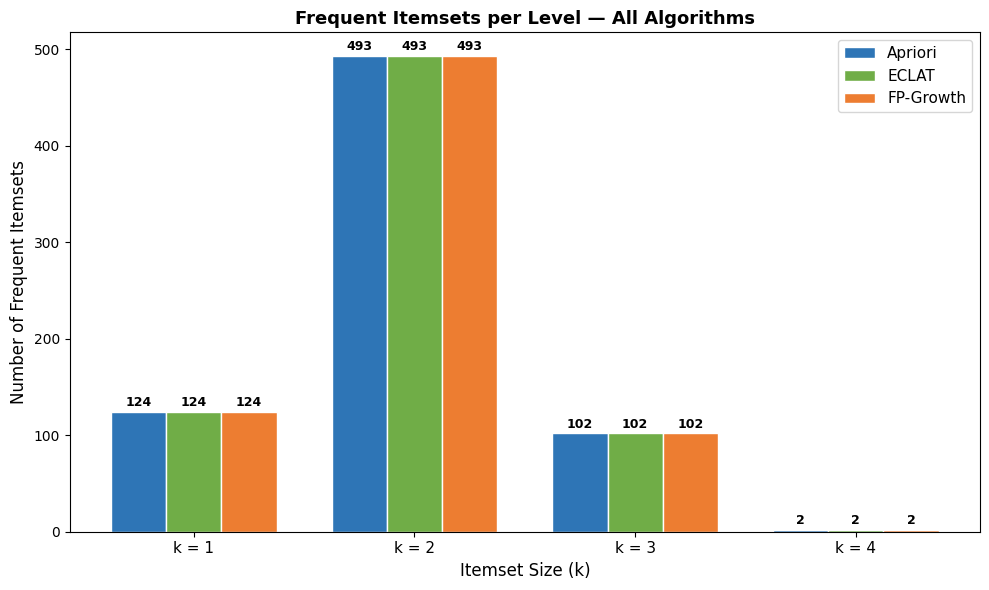

  saved → plot_03_levels.png


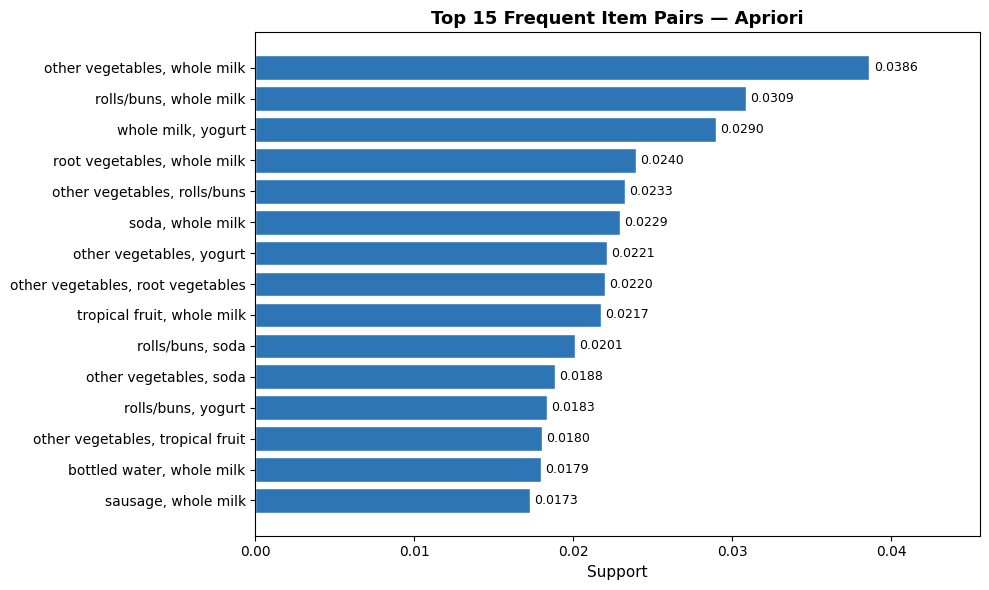

  saved → plot_04_pairs_apriori.png


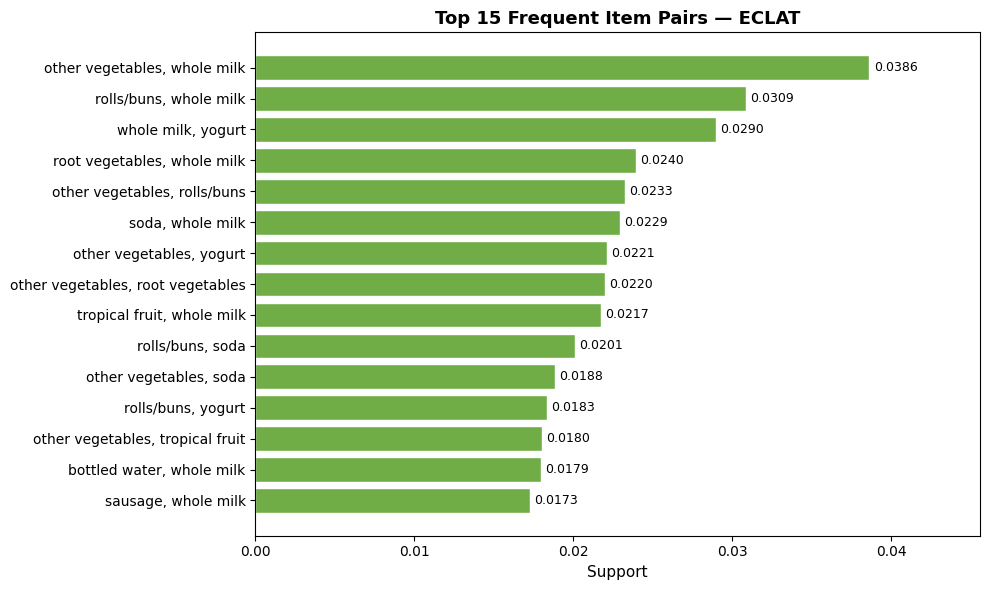

  saved → plot_04_pairs_eclat.png


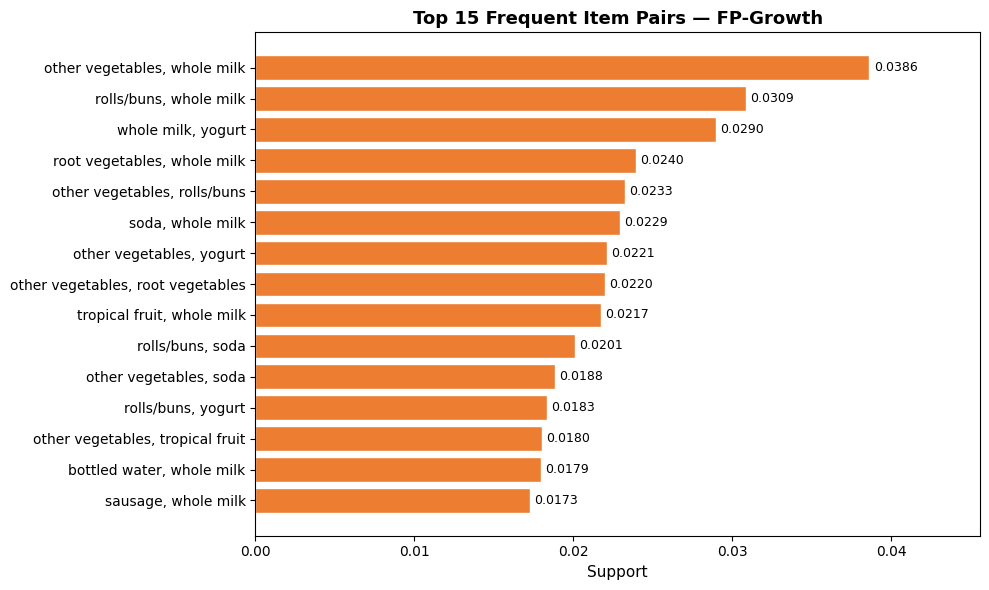

  saved → plot_04_pairs_fpg.png


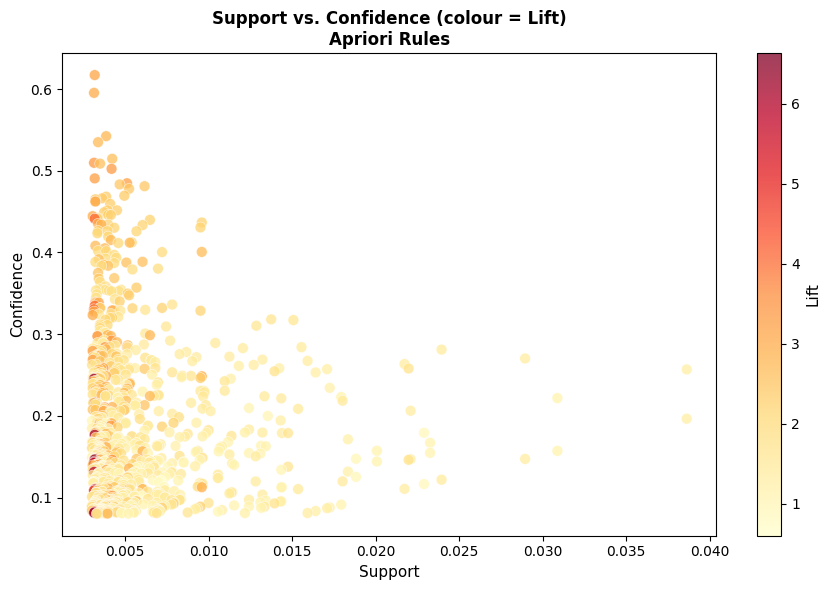

  saved → plot_05_scatter.png


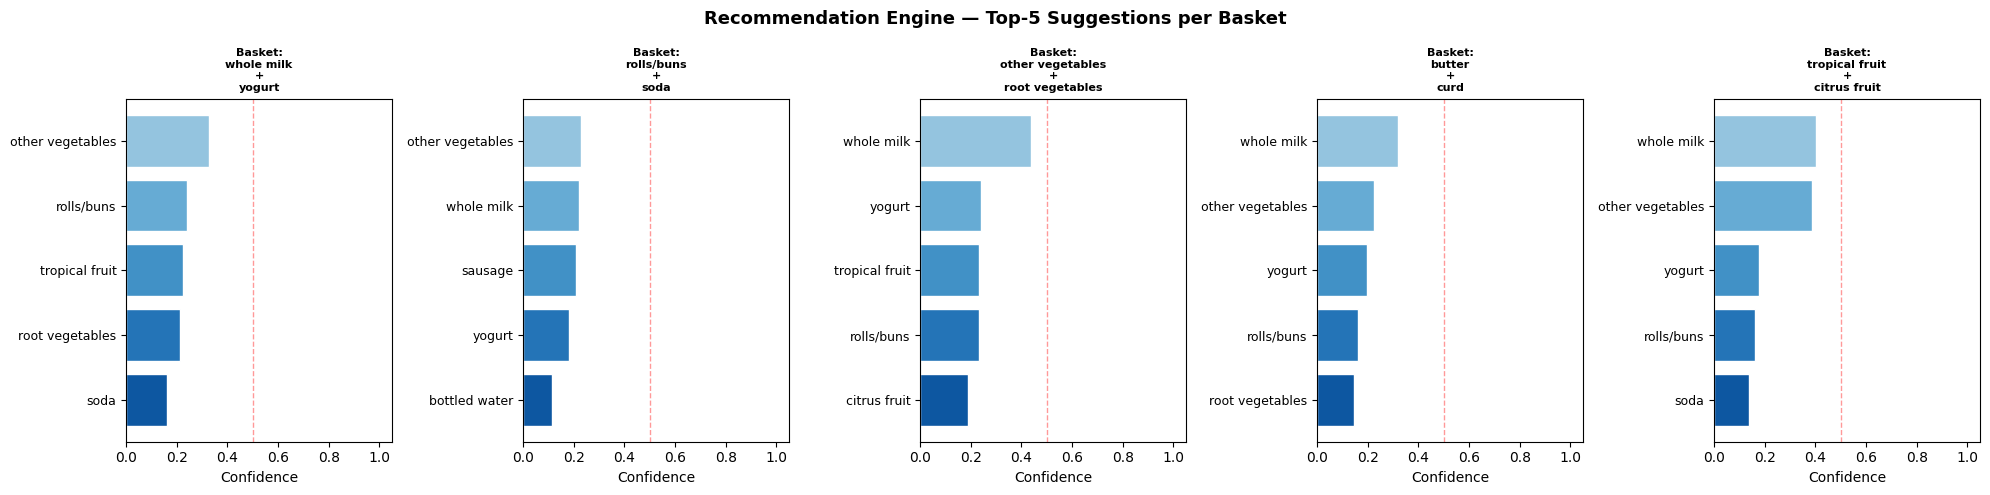

  saved → plot_07_recommendations.png


In [44]:
plot_benchmark(bench)
plot_levels(bench)
plot_top_pairs(F_apriori, n, "Apriori",   PALETTE[0], "plot_04_pairs_apriori.png")
plot_top_pairs(bench["ECLAT"]["F_all"],   bench["ECLAT"]["n"],     "ECLAT",     PALETTE[1], "plot_04_pairs_eclat.png")
plot_top_pairs(bench["FP-Growth"]["F_all"], bench["FP-Growth"]["n"], "FP-Growth", PALETTE[2], "plot_04_pairs_fpg.png")
plot_scatter(rules,       "Apriori Rules",  PALETTE[0], "plot_05_scatter.png")
plot_recommendations(rules)

In [45]:
print("  RECOMMENDATION DEMO")
print(f"{'═'*60}")
demos = [
    ["whole milk", "yogurt"],
    ["rolls/buns", "soda"],
    ["butter", "curd"],
    ["other vegetables", "root vegetables"],
]
for basket in demos:
    recs = recommend(basket, rules_by_lift, top_n=5)
    print(f"\n  Basket : {basket}")
    print(f"  Recommendations:")
    for item, conf in recs:
        print(f"    ➤  {item:<35} confidence = {conf:.4f}")

  RECOMMENDATION DEMO
════════════════════════════════════════════════════════════

  Basket : ['whole milk', 'yogurt']
  Recommendations:
    ➤  other vegetables                    confidence = 0.3287
    ➤  rolls/buns                          confidence = 0.2409
    ➤  tropical fruit                      confidence = 0.2242
    ➤  root vegetables                     confidence = 0.2131
    ➤  soda                                confidence = 0.1630

  Basket : ['rolls/buns', 'soda']
  Recommendations:
    ➤  other vegetables                    confidence = 0.2289
    ➤  whole milk                          confidence = 0.2217
    ➤  sausage                             confidence = 0.2108
    ➤  yogurt                              confidence = 0.1807
    ➤  bottled water                       confidence = 0.1127

  Basket : ['butter', 'curd']
  Recommendations:
    ➤  whole milk                          confidence = 0.3181
    ➤  other vegetables                    confidence = 0.2239
 